# 🏦 Banking Customer Support AI Agent using Multi-Agent Architecture

**Applied Generative AI Specialisation — Capstone Project**

This notebook designs and implements a **multi-agent GenAI system** for banking
customer support:

| Agent | Responsibility |
|---|---|
| **1. Classifier Agent** | Categorises each message as *Positive Feedback*, *Negative Feedback*, or *Query* and routes it |
| **2. Feedback Handler Agent** | Positive → personalised thank-you · Negative → creates a unique 6-digit ticket in the `support_tickets` DB + empathetic reply |
| **3. Query Handler Agent** | Extracts the ticket number, looks it up in SQLite, and reports its status |

**Stack:** LangGraph (agent orchestration) · Groq LLM (configurable API key) ·
SQLite (`support_tickets`) · Streamlit (interactive UI — see
`banking_support_app.py`).

A **rule-based fallback engine** keeps every workflow fully functional when no
API key is configured, so the notebook runs end-to-end offline as well.

## 1. Setup & Configuration

Install the requirements once (uncomment on first run), then configure the
Groq API key. The key is **configurable**: paste it below or set the
`GROQ_API_KEY` environment variable — leave it empty to use the fallback
engine.

In [1]:
!pip install langgraph langchain-groq langchain-core pandas matplotlib streamlit

import json
import os
import random
import re
import sqlite3
import time
from datetime import datetime
from typing import List, Optional, TypedDict

import pandas as pd
from langgraph.graph import END, StateGraph

try:
    from langchain_groq import ChatGroq
    from langchain_core.messages import HumanMessage, SystemMessage
    GROQ_SDK_AVAILABLE = True
except ImportError:
    GROQ_SDK_AVAILABLE = False

# ------------------------------------------------------------------
# CONFIGURABLE: paste your Groq API key here (or set env GROQ_API_KEY)
# ------------------------------------------------------------------
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")   # e.g. "gsk_..."
GROQ_MODEL = "llama-3.1-8b-instant"

DB_PATH = "support_tickets.db"
CATEGORIES = ["Positive Feedback", "Negative Feedback", "Query"]
print("LLM mode:", "Groq" if (GROQ_SDK_AVAILABLE and GROQ_API_KEY) else "rule-based fallback")

zsh:1: command not found: pip


LLM mode: rule-based fallback


## 2. Support Database (SQLite)

Two tables are used:
* **`support_tickets`** — the ticket store required by the problem statement
  (unique 6-digit `ticket_id`, customer, issue, status, timestamps), seeded
  with sample tickets so the query flow can be demonstrated immediately.
* **`interaction_logs`** — every pipeline run is logged here for the LLMOps
  part (agent path, ticket action, latency, engine used, prompt traces).

In [2]:
SEED_TICKETS = [
    (650932, "Priya Sharma", "Debit card replacement not received", "Resolved"),
    (784521, "Rahul Verma", "Net banking login failure", "In Progress"),
    (213377, "Anita Desai", "Unexpected charge on savings account", "Unresolved"),
    (445210, "David Mathew", "Credit card statement discrepancy", "Resolved"),
    (908764, "Sneha Iyer", "UPI transaction stuck in pending state", "In Progress"),
    (562148, "Arjun Nair", "Cheque book request not processed", "Unresolved"),
]


def get_conn():
    return sqlite3.connect(DB_PATH, check_same_thread=False)


def init_db():
    with get_conn() as conn:
        conn.execute(
            """CREATE TABLE IF NOT EXISTS support_tickets (
                   ticket_id INTEGER PRIMARY KEY, customer_name TEXT,
                   issue_description TEXT, status TEXT DEFAULT 'Unresolved',
                   created_at TEXT, updated_at TEXT)"""
        )
        conn.execute(
            """CREATE TABLE IF NOT EXISTS interaction_logs (
                   log_id INTEGER PRIMARY KEY AUTOINCREMENT, timestamp TEXT,
                   user_input TEXT, classification TEXT, agent_path TEXT,
                   response TEXT, ticket_action TEXT, latency_ms REAL,
                   llm_used INTEGER, success INTEGER, prompt_trace TEXT)"""
        )
        if conn.execute("SELECT COUNT(*) FROM support_tickets").fetchone()[0] == 0:
            now = datetime.now().isoformat(timespec="seconds")
            conn.executemany(
                "INSERT INTO support_tickets VALUES (?,?,?,?,?,?)",
                [(t, n, i, s, now, now) for t, n, i, s in SEED_TICKETS],
            )


def generate_ticket_number(conn):
    """Generate a unique 6-digit ticket number."""
    while True:
        candidate = random.randint(100000, 999999)
        if conn.execute("SELECT 1 FROM support_tickets WHERE ticket_id=?",
                        (candidate,)).fetchone() is None:
            return candidate


def create_ticket(customer_name, issue_description):
    """Insert a new unresolved ticket and return its 6-digit number."""
    with get_conn() as conn:
        ticket_id = generate_ticket_number(conn)
        now = datetime.now().isoformat(timespec="seconds")
        conn.execute("INSERT INTO support_tickets VALUES (?,?,?,?,?,?)",
                     (ticket_id, customer_name, issue_description,
                      "Unresolved", now, now))
    return ticket_id


def get_ticket_status(ticket_id):
    with get_conn() as conn:
        row = conn.execute("SELECT status FROM support_tickets WHERE ticket_id=?",
                           (ticket_id,)).fetchone()
    return row[0] if row else None


def log_interaction(state, latency_ms, success):
    with get_conn() as conn:
        conn.execute(
            "INSERT INTO interaction_logs (timestamp, user_input, classification,"
            " agent_path, response, ticket_action, latency_ms, llm_used, success,"
            " prompt_trace) VALUES (?,?,?,?,?,?,?,?,?,?)",
            (datetime.now().isoformat(timespec="seconds"),
             state.get("message", ""), state.get("category", ""),
             " → ".join(state.get("agent_path", [])), state.get("response", ""),
             state.get("ticket_action", "None"), round(latency_ms, 1),
             int(state.get("llm_used", False)), int(success),
             json.dumps(state.get("prompt_trace", []))))


init_db()
pd.read_sql_query("SELECT * FROM support_tickets", get_conn())

,ticket_id,customer_name,issue_description,status,created_at,updated_at
0,213377,Anita Desai,Unexpected charge on savings account,Unresolved,2026-08-16T09:47:43,2026-08-16T09:47:43
1,445210,David Mathew,Credit card statement discrepancy,Resolved,2026-08-16T09:47:43,2026-08-16T09:47:43
2,562148,Arjun Nair,Cheque book request not processed,Unresolved,2026-08-16T09:47:43,2026-08-16T09:47:43
3,650932,Priya Sharma,Debit card replacement not received,Resolved,2026-08-16T09:47:43,2026-08-16T09:47:43
4,784521,Rahul Verma,Net banking login failure,In Progress,2026-08-16T09:47:43,2026-08-16T09:47:43
5,908764,Sneha Iyer,UPI transaction stuck in pending state,In Progress,2026-08-16T09:47:43,2026-08-16T09:47:43


## 3. LLM Helper (Groq — with graceful fallback)

`llm_call()` returns `None` on any failure (missing key, network error,
rate limit), so every agent can fall back to a deterministic template and the
system never crashes — an important reliability property for LLMOps.

In [3]:
def get_llm():
    if not (GROQ_SDK_AVAILABLE and GROQ_API_KEY):
        return None
    return ChatGroq(groq_api_key=GROQ_API_KEY, model_name=GROQ_MODEL,
                    temperature=0.3, max_tokens=200)


def llm_call(system_prompt, user_prompt):
    llm = get_llm()
    if llm is None:
        return None
    try:
        reply = llm.invoke([SystemMessage(content=system_prompt),
                            HumanMessage(content=user_prompt)])
        return reply.content.strip()
    except Exception:
        return None

## 4. Shared Agent State & Utilities

All agents read and write a common `AgentState` dictionary that flows through
the LangGraph workflow — message, extracted customer name, classification,
response, ticket action, the ordered **agent path**, and full prompt traces.

In [4]:
class AgentState(TypedDict, total=False):
    message: str
    customer_name: str
    category: str
    response: str
    ticket_id: Optional[int]
    ticket_action: str
    agent_path: List[str]
    prompt_trace: List[dict]
    llm_used: bool


def extract_customer_name(message, provided=""):
    if provided and provided.strip():
        return provided.strip()
    m = re.search(r"(?:my name is|this is|i am|i'm)\s+"
                  r"([A-Z][a-zA-Z]+(?:\s[A-Z][a-zA-Z]+)?)",
                  message, flags=re.IGNORECASE)
    return m.group(1).strip().title() if m else "Valued Customer"


def extract_ticket_number(message):
    m = re.search(r"#?\b(\d{6})\b", message)
    return int(m.group(1)) if m else None

## 5. Agent 1 — Classifier Agent

Classifies the message with the Groq LLM (strict single-label prompt). When
the LLM is unavailable, a keyword-scoring fallback takes over. The routing
decision and full prompt trace are recorded in the state.

In [5]:
CLASSIFIER_SYSTEM_PROMPT = (
    "You are a message classifier for a bank's customer support system.\n"
    "Classify the user's message into exactly one category:\n"
    "  POSITIVE_FEEDBACK — the customer is thanking us or praising the service.\n"
    "  NEGATIVE_FEEDBACK — the customer is complaining or reporting a problem "
    "and is NOT asking about an existing ticket.\n"
    "  QUERY — the customer asks about the status of an existing support "
    "ticket, or asks a service question (usually mentions a ticket number).\n"
    "Respond with ONLY the category label, nothing else."
)

POSITIVE_WORDS = ["thank", "thanks", "great", "excellent", "awesome",
                  "wonderful", "amazing", "appreciate", "happy", "delighted",
                  "resolved my", "sorted", "helpful", "quick", "love",
                  "good service", "well done", "kudos", "fantastic", "best"]
NEGATIVE_WORDS = ["not ", "n't", "no ", "issue", "problem", "complaint",
                  "poor", "bad", "delay", "delayed", "failed", "failure",
                  "error", "wrong", "unhappy", "frustrated", "disappointed",
                  "waiting", "stuck", "pending", "unable", "charged",
                  "deducted", "blocked", "worst", "terrible", "never", "missing"]
QUERY_WORDS = ["status", "update on", "check", "track", "progress", "any news",
               "what happened to", "where is", "when will", "follow up",
               "followup"]


def fallback_classify(message):
    """Deterministic keyword classifier used when the LLM is unavailable."""
    text = message.lower()
    has_ticket_ref = extract_ticket_number(message) is not None or "ticket" in text
    query_score = sum(1 for w in QUERY_WORDS if w in text)
    if has_ticket_ref and (query_score > 0 or "?" in text):
        return "Query"
    positive_score = sum(1 for w in POSITIVE_WORDS if w in text)
    negative_score = sum(1 for w in NEGATIVE_WORDS if w in text)
    if positive_score > negative_score:
        return "Positive Feedback"
    if negative_score > 0:
        return "Negative Feedback"
    if query_score > 0 or "?" in text:
        return "Query"
    return "Negative Feedback"


def classifier_agent(state):
    message = state["message"]
    label_map = {"POSITIVE_FEEDBACK": "Positive Feedback",
                 "NEGATIVE_FEEDBACK": "Negative Feedback",
                 "QUERY": "Query"}
    raw = llm_call(CLASSIFIER_SYSTEM_PROMPT, message)
    category = None
    if raw is not None:
        cleaned = raw.upper().replace(" ", "_").strip()
        for key, value in label_map.items():
            if key in cleaned:
                category = value
                break
    llm_used = category is not None
    if category is None:
        category = fallback_classify(message)
    state["category"] = category
    state["llm_used"] = state.get("llm_used", False) or llm_used
    state.setdefault("agent_path", []).append("Classifier Agent")
    state.setdefault("prompt_trace", []).append(
        {"agent": "Classifier Agent",
         "engine": "LLM" if llm_used else "Rule-based fallback",
         "prompt": CLASSIFIER_SYSTEM_PROMPT + "\n\nUSER: " + message,
         "output": raw if raw is not None else category,
         "decision": category})
    return state


def route_by_category(state):
    """Conditional edge — route to the downstream agent for the category."""
    return {"Positive Feedback": "positive_feedback_handler",
            "Negative Feedback": "negative_feedback_handler",
            "Query": "query_handler"}[state["category"]]

## 6. Agent 2 — Feedback Handler Agent

* **Positive feedback** → warm, personalised thank-you
  (`Thank you for your kind words, [CustomerName]! …`).
* **Negative feedback** → generates a **unique 6-digit ticket**, inserts an
  *Unresolved* row into `support_tickets`, and returns an empathetic message
  that always contains the ticket number.

In [6]:
def positive_feedback_agent(state):
    name = state["customer_name"]
    system = ("You are a warm, professional bank customer-support agent. The "
              "customer has left positive feedback. Write a SHORT (1-2 "
              f"sentence) personalised thank-you addressed to {name}. Mention "
              "what they thanked us for if clear from their message. "
              "No placeholders, no sign-off.")
    reply = llm_call(system, state["message"])
    llm_used = reply is not None
    if reply is None:
        reply = (f"Thank you for your kind words, {name}! "
                 "We're delighted to assist you.")
    state["response"] = reply
    state["ticket_action"] = "None"
    state["llm_used"] = state.get("llm_used", False) or llm_used
    state.setdefault("agent_path", []).append("Positive Feedback Handler")
    state.setdefault("prompt_trace", []).append(
        {"agent": "Positive Feedback Handler",
         "engine": "LLM" if llm_used else "Template fallback",
         "prompt": system + "\n\nUSER: " + state["message"],
         "output": reply, "decision": "Thank-you message generated"})
    return state


def negative_feedback_agent(state):
    name = state["customer_name"]
    ticket_id = create_ticket(name, state["message"])
    state["ticket_id"] = ticket_id
    state["ticket_action"] = f"Created ticket #{ticket_id} (Unresolved)"
    system = ("You are an empathetic bank customer-support agent. The customer "
              "has a complaint. Apologise sincerely in 1-2 sentences and tell "
              f"them that ticket #{ticket_id} has been created and our team "
              "will follow up shortly. You MUST include the exact ticket "
              f"number #{ticket_id}.")
    reply = llm_call(system, state["message"])
    llm_used = reply is not None
    if reply is None or str(ticket_id) not in reply:
        reply = (f"We apologize for the inconvenience, {name}. A new ticket "
                 f"#{ticket_id} has been generated, and our team will follow "
                 "up shortly.")
    state["response"] = reply
    state["llm_used"] = state.get("llm_used", False) or llm_used
    state.setdefault("agent_path", []).append("Negative Feedback Handler")
    state.setdefault("prompt_trace", []).append(
        {"agent": "Negative Feedback Handler",
         "engine": "LLM" if llm_used else "Template fallback",
         "prompt": system + "\n\nUSER: " + state["message"],
         "output": reply, "decision": state["ticket_action"]})
    return state

## 7. Agent 3 — Query Handler Agent

Extracts a 6-digit ticket number with a regex, queries `support_tickets`,
and answers in the required format
(`Your ticket #NNNNNN is currently marked as: Status.`), with graceful
handling of missing or unknown ticket numbers.

In [7]:
def query_handler_agent(state):
    ticket_id = extract_ticket_number(state["message"])
    if ticket_id is None:
        state["response"] = ("I'd be happy to check that for you. Could you "
                             "please share your 6-digit ticket number?")
        state["ticket_action"] = "No ticket number found in message"
    else:
        status = get_ticket_status(ticket_id)
        state["ticket_id"] = ticket_id
        if status is None:
            state["response"] = (f"I'm sorry, ticket #{ticket_id} was not "
                                 "found in our system. Please verify the "
                                 "number and try again.")
            state["ticket_action"] = f"Lookup failed — ticket #{ticket_id} not found"
        else:
            state["response"] = (f"Your ticket #{ticket_id} is currently "
                                 f"marked as: {status}.")
            state["ticket_action"] = f"Looked up ticket #{ticket_id} → {status}"
    state.setdefault("agent_path", []).append("Query Handler")
    state.setdefault("prompt_trace", []).append(
        {"agent": "Query Handler", "engine": "Deterministic (regex + SQL)",
         "prompt": f"Extract ticket number from: {state['message']}",
         "output": state["response"], "decision": state["ticket_action"]})
    return state

## 8. LangGraph Workflow — Wiring the Agents Together

The classifier is the entry point; a **conditional edge** routes the state to
the matching handler, and every handler terminates the graph:

```
                   ┌────────────────────────────┐
    user message → │      Classifier Agent      │
                   └──────────────┬─────────────┘
           ┌──────────────────────┼──────────────────────┐
           ▼                      ▼                      ▼
  Positive Feedback      Negative Feedback          Query Handler
       Handler                Handler              (regex + SQL)
    (thank-you)      (6-digit ticket → DB insert)  (status lookup)
           └──────────────────────┴──────────────────────┘
                                  ▼
                           response + logs
```

In [8]:
def build_graph():
    graph = StateGraph(AgentState)
    graph.add_node("classifier", classifier_agent)
    graph.add_node("positive_feedback_handler", positive_feedback_agent)
    graph.add_node("negative_feedback_handler", negative_feedback_agent)
    graph.add_node("query_handler", query_handler_agent)
    graph.set_entry_point("classifier")
    graph.add_conditional_edges(
        "classifier", route_by_category,
        {"positive_feedback_handler": "positive_feedback_handler",
         "negative_feedback_handler": "negative_feedback_handler",
         "query_handler": "query_handler"})
    graph.add_edge("positive_feedback_handler", END)
    graph.add_edge("negative_feedback_handler", END)
    graph.add_edge("query_handler", END)
    return graph.compile()


WORKFLOW = build_graph()


def run_pipeline(message, customer_name=""):
    """Run one message through the multi-agent workflow and log the result."""
    initial = {"message": message,
               "customer_name": extract_customer_name(message, customer_name),
               "agent_path": [], "prompt_trace": [], "llm_used": False}
    start = time.time()
    success = True
    try:
        final = WORKFLOW.invoke(initial)
    except Exception as exc:
        final = dict(initial)
        final["category"] = "Error"
        final["response"] = f"Sorry, something went wrong: {exc}"
        final["ticket_action"] = "Pipeline error"
        success = False
    latency_ms = (time.time() - start) * 1000
    final["latency_ms"] = latency_ms
    final["success"] = success
    log_interaction(final, latency_ms, success)
    return final

## 9. Demonstration — the Three Canonical Use-Case Flows

These are the exact sample flows from the problem statement.

In [9]:
def demo(message):
    r = run_pipeline(message)
    print("USER    :", message)
    print("CATEGORY:", r["category"])
    print("PATH    :", "  →  ".join(r["agent_path"]))
    print("RESPONSE:", r["response"])
    print("DB      :", r.get("ticket_action"))
    print("-" * 72)


demo("Thanks for sorting out my net banking login issue.")
demo("My debit card replacement still hasn't arrived.")
demo("Could you check the status of ticket 650932?")

USER    : Thanks for sorting out my net banking login issue.
CATEGORY: Positive Feedback
PATH    : Classifier Agent  →  Positive Feedback Handler
RESPONSE: Thank you for your kind words, Valued Customer! We're delighted to assist you.
DB      : None
------------------------------------------------------------------------
USER    : My debit card replacement still hasn't arrived.
CATEGORY: Negative Feedback
PATH    : Classifier Agent  →  Negative Feedback Handler
RESPONSE: We apologize for the inconvenience, Valued Customer. A new ticket #619501 has been generated, and our team will follow up shortly.
DB      : Created ticket #619501 (Unresolved)
------------------------------------------------------------------------
USER    : Could you check the status of ticket 650932?
CATEGORY: Query
PATH    : Classifier Agent  →  Query Handler
RESPONSE: Your ticket #650932 is currently marked as: Resolved.
DB      : Looked up ticket #650932 → Resolved
------------------------------------------------

## 10. LLMOps — Model Evaluation

A labelled test suite of **30 banking messages** (10 per category) measures:

* **Classification accuracy** (overall and per class)
* **Agent routing success rate** — did the state reach the correct handler?
* **QA pass rate** — does each response satisfy the required format/content
  (empathy + ticket number for complaints, status format for queries, …)?

When a Groq key is configured, an optional **LLM-as-judge** scores responses
1–5 on *empathy, clarity, accuracy*.

In [10]:
EXPECTED_AGENT = {"Positive Feedback": "Positive Feedback Handler",
                  "Negative Feedback": "Negative Feedback Handler",
                  "Query": "Query Handler"}

TEST_CASES = [
    ("Thanks for sorting out my net banking login issue.", "Positive Feedback"),
    ("Thank you for resolving my credit card issue so quickly!", "Positive Feedback"),
    ("Great service at the branch today, really appreciate it.", "Positive Feedback"),
    ("My name is Ramesh and I want to say the staff was excellent.", "Positive Feedback"),
    ("Awesome! My loan got approved in just two days. Thanks a lot.", "Positive Feedback"),
    ("I appreciate the quick help with my UPI problem yesterday.", "Positive Feedback"),
    ("The mobile app update is wonderful, well done team.", "Positive Feedback"),
    ("Kudos to your support team for the fantastic assistance.", "Positive Feedback"),
    ("I'm delighted with how fast my chequebook arrived. Thank you!", "Positive Feedback"),
    ("Best banking experience I've had, keep up the good service.", "Positive Feedback"),
    ("My debit card replacement still hasn't arrived.", "Negative Feedback"),
    ("I was charged twice for the same transaction, please fix this.", "Negative Feedback"),
    ("Net banking has been down for three days, this is frustrating.", "Negative Feedback"),
    ("This is Anjali. My cheque book request was never processed.", "Negative Feedback"),
    ("Very poor service — my complaint about the ATM was ignored.", "Negative Feedback"),
    ("My UPI payment failed but the money was deducted from my account.", "Negative Feedback"),
    ("I am unhappy with the delay in my loan disbursement.", "Negative Feedback"),
    ("The branch staff was rude and my issue is still unresolved.", "Negative Feedback"),
    ("My account got blocked without any notice, this is terrible.", "Negative Feedback"),
    ("I have been waiting two weeks for my fixed deposit receipt.", "Negative Feedback"),
    ("Could you check the status of ticket 650932?", "Query"),
    ("What is the update on my ticket #784521?", "Query"),
    ("Please tell me the progress of ticket number 213377.", "Query"),
    ("Any news on ticket 445210?", "Query"),
    ("I want to track my complaint, ticket #908764.", "Query"),
    ("When will ticket 562148 be resolved? Please check the status.", "Query"),
    ("Can you give me a status update on ticket #650932?", "Query"),
    ("What happened to my ticket 784521? Please check.", "Query"),
    ("Status of my support ticket 213377 please.", "Query"),
    ("Follow up on ticket #445210 — what is the current status?", "Query"),
]


def qa_check_response(category, response):
    """Rule-based QA: does the response satisfy the required format/content?"""
    text = response.lower()
    if category == "Positive Feedback":
        return any(w in text for w in ["thank", "delighted", "appreciate",
                                       "glad", "happy"])
    if category == "Negative Feedback":
        return (re.search(r"#\d{6}", response) is not None and
                any(w in text for w in ["apolog", "sorry", "regret",
                                        "inconvenience"]))
    if category == "Query":
        return (("marked as" in text
                 and re.search(r"#\d{6}", response) is not None)
                or "not found" in text or "ticket number" in text)
    return False


rows = []
for message, expected in TEST_CASES:
    result = run_pipeline(message)
    predicted = result.get("category", "Error")
    routed_to = result["agent_path"][-1] if result.get("agent_path") else "None"
    rows.append({"Test Message": message, "Expected": expected,
                 "Predicted": predicted, "Correct": predicted == expected,
                 "Routed To": routed_to,
                 "Routing OK": routed_to == EXPECTED_AGENT.get(predicted, ""),
                 "QA Pass": qa_check_response(predicted,
                                              result.get("response", "")),
                 "Latency (ms)": round(result.get("latency_ms", 0), 1)})

eval_df = pd.DataFrame(rows)
metrics = {
    "Classification Accuracy": eval_df["Correct"].mean(),
    "Routing Success Rate": eval_df["Routing OK"].mean(),
    "QA Pass Rate": eval_df["QA Pass"].mean(),
    "Avg Latency (ms)": eval_df["Latency (ms)"].mean(),
}
for cat in CATEGORIES:
    metrics[f"Accuracy — {cat}"] = eval_df[eval_df["Expected"] == cat]["Correct"].mean()

print(json.dumps({k: round(v, 3) for k, v in metrics.items()}, indent=2))
eval_df.head(10)

{
  "Classification Accuracy": 1.0,
  "Routing Success Rate": 1.0,
  "QA Pass Rate": 1.0,
  "Avg Latency (ms)": 1.273,
  "Accuracy \u2014 Positive Feedback": 1.0,
  "Accuracy \u2014 Negative Feedback": 1.0,
  "Accuracy \u2014 Query": 1.0
}


,Test Message,Expected,Predicted,Correct,Routed To,Routing OK,QA Pass,Latency (ms)
0,Thanks for sorting out my net banking login is...,Positive Feedback,Positive Feedback,True,Positive Feedback Handler,True,True,1.2
1,Thank you for resolving my credit card issue s...,Positive Feedback,Positive Feedback,True,Positive Feedback Handler,True,True,1.2
2,"Great service at the branch today, really appr...",Positive Feedback,Positive Feedback,True,Positive Feedback Handler,True,True,1.2
3,My name is Ramesh and I want to say the staff ...,Positive Feedback,Positive Feedback,True,Positive Feedback Handler,True,True,0.9
4,Awesome! My loan got approved in just two days...,Positive Feedback,Positive Feedback,True,Positive Feedback Handler,True,True,0.8
5,I appreciate the quick help with my UPI proble...,Positive Feedback,Positive Feedback,True,Positive Feedback Handler,True,True,0.8
6,"The mobile app update is wonderful, well done ...",Positive Feedback,Positive Feedback,True,Positive Feedback Handler,True,True,0.8
7,Kudos to your support team for the fantastic a...,Positive Feedback,Positive Feedback,True,Positive Feedback Handler,True,True,0.8
8,I'm delighted with how fast my chequebook arri...,Positive Feedback,Positive Feedback,True,Positive Feedback Handler,True,True,0.8
9,"Best banking experience I've had, keep up the ...",Positive Feedback,Positive Feedback,True,Positive Feedback Handler,True,True,0.8


### Evaluation summary chart

Matplotlib is building the font cache; this may take a moment.


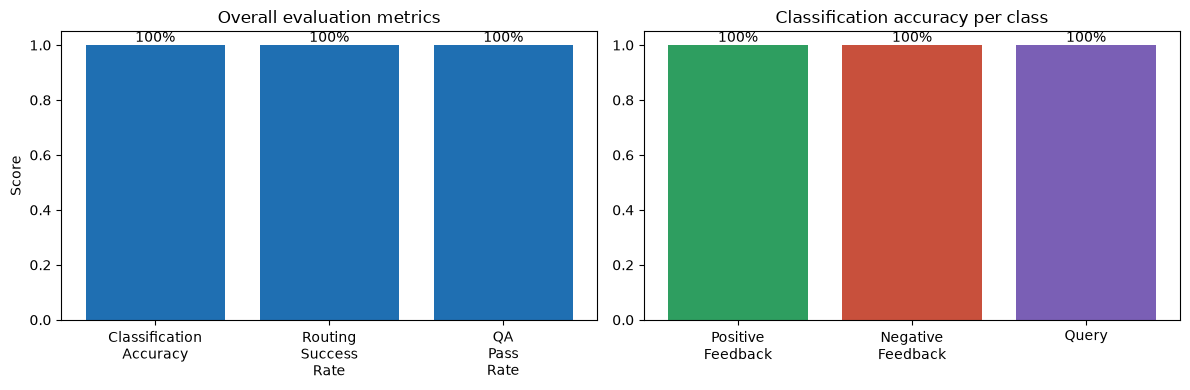

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
overall = ["Classification Accuracy", "Routing Success Rate", "QA Pass Rate"]
axes[0].bar([m.replace(" ", "\n") for m in overall],
            [metrics[m] for m in overall], color="#1f6fb2")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Overall evaluation metrics")
axes[0].set_ylabel("Score")
per_class = [metrics[f"Accuracy — {c}"] for c in CATEGORIES]
axes[1].bar([c.replace(" ", "\n") for c in CATEGORIES], per_class,
            color=["#2e9e60", "#c8503c", "#7a5fb5"])
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Classification accuracy per class")
for ax in axes:
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.0%}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Optional — LLM-as-judge QA scoring (runs only when a Groq key is set)

In [12]:
JUDGE_PROMPT = (
    "You are a strict QA reviewer for a bank's support chatbot. Score the "
    "agent response on three dimensions from 1 (poor) to 5 (excellent): "
    'empathy, clarity, accuracy. Reply ONLY with JSON like '
    '{"empathy": 4, "clarity": 5, "accuracy": 5}.'
)

if get_llm() is not None:
    judged = []
    for message, _ in TEST_CASES[:6]:
        result = run_pipeline(message)
        raw = llm_call(JUDGE_PROMPT,
                       f"Customer message: {message}\n"
                       f"Agent response: {result['response']}")
        if raw:
            m = re.search(r"\{.*\}", raw, flags=re.DOTALL)
            if m:
                try:
                    judged.append({"Message": message, **json.loads(m.group(0))})
                except json.JSONDecodeError:
                    pass
    display(pd.DataFrame(judged))
else:
    print("No Groq API key configured — skipping LLM-as-judge scoring.")

No Groq API key configured — skipping LLM-as-judge scoring.


## 11. Database State & Interaction Logs

Negative-feedback test cases above created new *Unresolved* tickets; every
single run was logged with its agent path, ticket action, and latency.

In [13]:
print("support_tickets:")
display(pd.read_sql_query(
    "SELECT * FROM support_tickets ORDER BY created_at DESC LIMIT 12",
    get_conn()))
print("interaction_logs (latest 8):")
display(pd.read_sql_query(
    "SELECT timestamp, user_input, classification, agent_path, ticket_action, "
    "latency_ms, success FROM interaction_logs ORDER BY log_id DESC LIMIT 8",
    get_conn()))

support_tickets:


,ticket_id,customer_name,issue_description,status,created_at,updated_at
0,213377,Anita Desai,Unexpected charge on savings account,Unresolved,2026-08-16T09:47:43,2026-08-16T09:47:43
1,283464,Valued Customer,The branch staff was rude and my issue is stil...,Unresolved,2026-08-16T09:47:43,2026-08-16T09:47:43
2,302522,Frustrating,"Net banking has been down for three days, this...",Unresolved,2026-08-16T09:47:43,2026-08-16T09:47:43
3,408733,Valued Customer,"I was charged twice for the same transaction, ...",Unresolved,2026-08-16T09:47:43,2026-08-16T09:47:43
4,445210,David Mathew,Credit card statement discrepancy,Resolved,2026-08-16T09:47:43,2026-08-16T09:47:43
5,546451,Valued Customer,My debit card replacement still hasn't arrived.,Unresolved,2026-08-16T09:47:43,2026-08-16T09:47:43
6,558461,Valued Customer,Very poor service — my complaint about the ATM...,Unresolved,2026-08-16T09:47:43,2026-08-16T09:47:43
7,562148,Arjun Nair,Cheque book request not processed,Unresolved,2026-08-16T09:47:43,2026-08-16T09:47:43
8,583676,Terrible,"My account got blocked without any notice, thi...",Unresolved,2026-08-16T09:47:43,2026-08-16T09:47:43
9,596796,Valued Customer,My UPI payment failed but the money was deduct...,Unresolved,2026-08-16T09:47:43,2026-08-16T09:47:43


interaction_logs (latest 8):


,timestamp,user_input,classification,agent_path,ticket_action,latency_ms,success
0,2026-08-16T09:47:43,Follow up on ticket #445210 — what is the curr...,Query,Classifier Agent → Query Handler,Looked up ticket #445210 → Resolved,0.9,1
1,2026-08-16T09:47:43,Status of my support ticket 213377 please.,Query,Classifier Agent → Query Handler,Looked up ticket #213377 → Unresolved,1.0,1
2,2026-08-16T09:47:43,What happened to my ticket 784521? Please check.,Query,Classifier Agent → Query Handler,Looked up ticket #784521 → In Progress,1.4,1
3,2026-08-16T09:47:43,Can you give me a status update on ticket #650...,Query,Classifier Agent → Query Handler,Looked up ticket #650932 → Resolved,0.9,1
4,2026-08-16T09:47:43,When will ticket 562148 be resolved? Please ch...,Query,Classifier Agent → Query Handler,Looked up ticket #562148 → Unresolved,1.0,1
5,2026-08-16T09:47:43,"I want to track my complaint, ticket #908764.",Query,Classifier Agent → Query Handler,Looked up ticket #908764 → In Progress,1.0,1
6,2026-08-16T09:47:43,Any news on ticket 445210?,Query,Classifier Agent → Query Handler,Looked up ticket #445210 → Resolved,1.4,1
7,2026-08-16T09:47:43,Please tell me the progress of ticket number 2...,Query,Classifier Agent → Query Handler,Looked up ticket #213377 → Unresolved,1.0,1


## 12. Streamlit User Interface

The interactive dashboard lives in **`banking_support_app.py`** (same agents,
same database). It provides five views:

1. **💬 Assistant** — chat that shows the classification, agent path,
   response, and database interaction for every message
2. **🎫 Ticket Database** — live view of `support_tickets` with status
   filters and metrics
3. **📊 Evaluation** — one-click run of the 30-case suite with metric cards
   and charts, plus optional LLM-as-judge scoring
4. **🧾 Logs & Debug** — interaction logs, success rates, and a per-message
   **prompt trace inspector**
5. **🧪 Test Scenarios** — the three canonical flows, runnable with one click

Run it with:

```bash
streamlit run banking_support_app.py
```

The Groq API key is configurable in the sidebar (or via the `GROQ_API_KEY`
environment variable); without a key the app transparently switches to the
rule-based fallback engine.

## 13. Conclusion

The system fulfils every requirement of the capstone problem statement:
a Classifier Agent routing to Feedback and Query handler agents via LangGraph
conditional edges; automatic unique 6-digit ticket creation in a SQLite
`support_tickets` table; personalised, empathetic LLM responses with reliable
fallbacks; and a complete LLMOps layer — evaluation suite, QA scoring,
structured logging with prompt traces, and an interactive Streamlit UI.